In [1]:
# Basic libraries
import pandas as pd
import numpy as np
import json
import os

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import xgboost as xgb
import joblib


In [2]:
# Load your new CSV dataset
df = pd.read_csv(r"C:\Users\syeds\OneDrive\Documents\Desktop\CyberAI-NextGen-Defender\CyberAI-NextGen-Defender\data\phishing\Phishing.csv")  
# Inspect the data
print("Shape:", df.shape)
print(df.head())

# Check for missing values
print(df.isnull().sum())


Shape: (10000, 50)
   id  NumDots  SubdomainLevel  PathLevel  UrlLength  NumDash  \
0   1        3               1          5         72        0   
1   2        3               1          3        144        0   
2   3        3               1          2         58        0   
3   4        3               1          6         79        1   
4   5        3               0          4         46        0   

   NumDashInHostname  AtSymbol  TildeSymbol  NumUnderscore  ...  \
0                  0         0            0              0  ...   
1                  0         0            0              2  ...   
2                  0         0            0              0  ...   
3                  0         0            0              0  ...   
4                  0         0            0              0  ...   

   IframeOrFrame  MissingTitle  ImagesOnlyInForm  SubdomainLevelRT  \
0              0             0                 1                 1   
1              0             0                 

In [3]:
# Drop unnecessary columns
X = df.drop(columns=['id', 'CLASS_LABEL'])
y = df['CLASS_LABEL']

# Replace -1 with 0 (or median) if needed
X = X.replace(-1, 0)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Save scaler
os.makedirs("models", exist_ok=True)
joblib.dump(scaler, "models/phishing_scaler.joblib")


['models/phishing_scaler.joblib']

In [4]:
X = df.drop(columns=['id', 'CLASS_LABEL'])
y = df['CLASS_LABEL']


In [5]:
X = X.replace(-1, 0)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


In [8]:
os.makedirs("models", exist_ok=True)
joblib.dump(scaler, "models/phishing_scaler.joblib")


['models/phishing_scaler.joblib']

In [9]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd
import numpy as np
import joblib
import os
import json

# Create models directory if not exists
os.makedirs("models", exist_ok=True)

# ------------------------
# Train XGBoost Classifier
# ------------------------
xgb_model = xgb.XGBClassifier(
    n_estimators=250, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, eval_metric='logloss',
    random_state=42
)

xgb_model.fit(
    X_train_scaled, y_train
)

# Save model
xgb_model.save_model("models/phishing_xgb.json")
print("Saved XGBoost model -> models/phishing_xgb.json")

# ------------------------
# Evaluate Model
# ------------------------
y_pred = xgb_model.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

# ------------------------
# Defender Simulation
# ------------------------
# Make predictions and probabilities
y_prob = xgb_model.predict_proba(X_test_scaled)[:,1]  # probability of class 1
actions = []

# Define thresholds for defender
block_threshold = 0.90
monitor_threshold = 0.60

for prob in y_prob:
    if prob >= block_threshold:
        actions.append("block_ip")
    elif prob >= monitor_threshold:
        actions.append("monitor")
    else:
        actions.append("allow")

# Prepare defender results DataFrame
defender_df = pd.DataFrame({
    "predicted_label": y_pred,
    "prediction_prob": y_prob,
    "defense_action": actions
})

# Save defender results
defender_df.to_csv("models/phishing_defense_results.csv", index=False)
print("Defender results saved -> models/phishing_defense_results.csv")

# Save action log (optional for UI or audit)
defender_df["ip"] = np.arange(len(defender_df))  # placeholder for email/IP index
defender_df.to_csv("models/phishing_defender_action_log.csv", index=False)
print("Action log saved -> models/phishing_defender_action_log.csv")

# ------------------------
# Save top features importance
# ------------------------
feature_importance = xgb_model.get_booster().get_score(importance_type='gain')
top_features = dict(sorted(feature_importance.items(), key=lambda item: item[1], reverse=True)[:20])

with open("models/phishing_artifacts_summary.json", "w") as f:
    json.dump({"top_features_gain": top_features}, f, indent=4)
print("Saved summary -> models/phishing_artifacts_summary.json")


Saved XGBoost model -> models/phishing_xgb.json
Accuracy: 0.9865

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      1000
           1       0.99      0.99      0.99      1000

    accuracy                           0.99      2000
   macro avg       0.99      0.99      0.99      2000
weighted avg       0.99      0.99      0.99      2000


Confusion Matrix:
 [[986  14]
 [ 13 987]]
Defender results saved -> models/phishing_defense_results.csv
Action log saved -> models/phishing_defender_action_log.csv
Saved summary -> models/phishing_artifacts_summary.json


 98%|===================| 1962/2000 [00:15<00:00]        

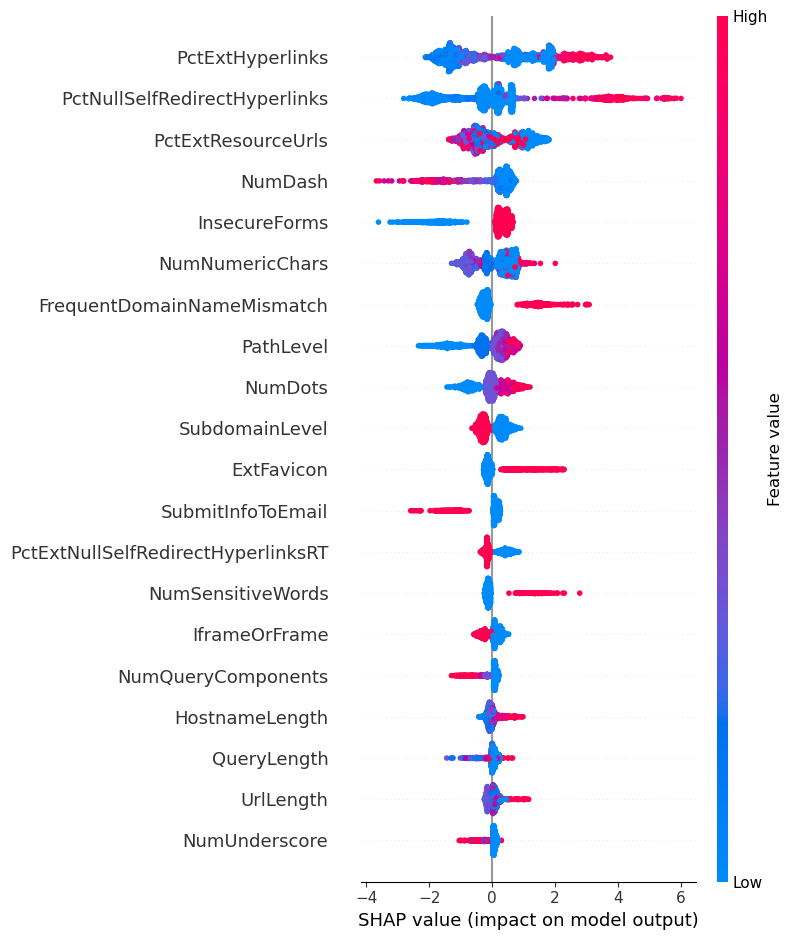

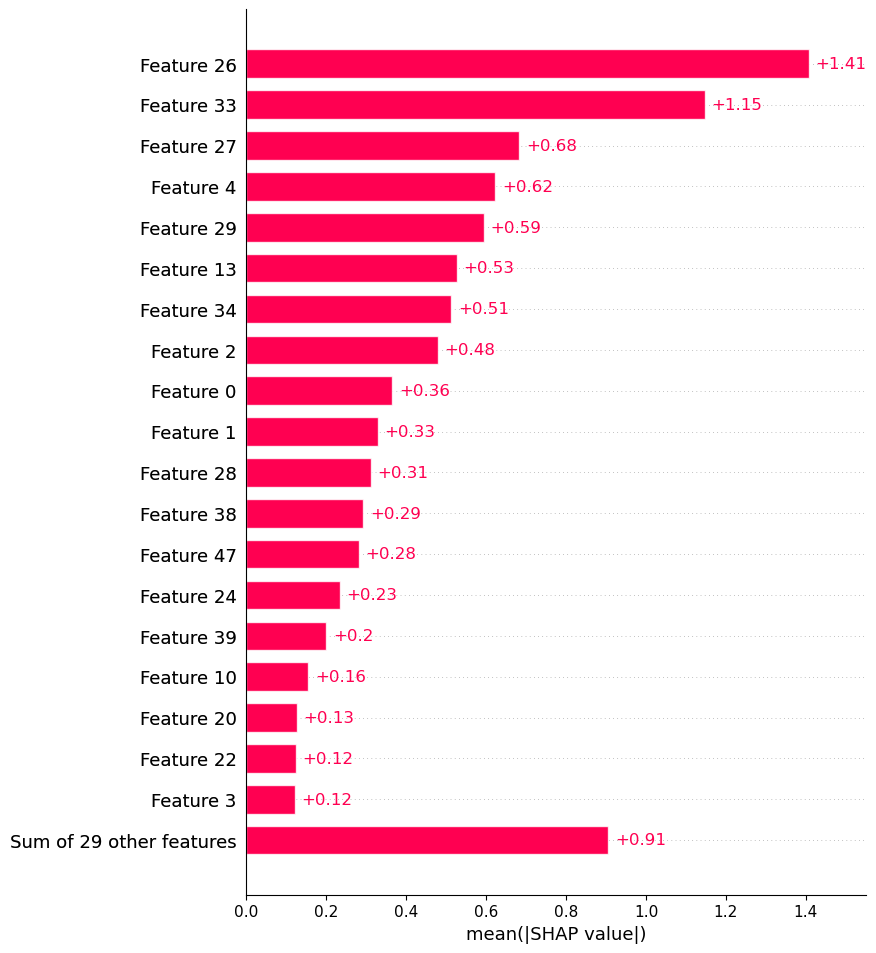

SHAP values saved -> models/phishing_shap_values.csv


In [10]:
import shap
import matplotlib.pyplot as plt
import pandas as pd

# Load scaler and scale full dataset (optional if you already have X_train_scaled)
# X_scaled = scaler.transform(X)  

# Initialize SHAP explainer
explainer = shap.Explainer(xgb_model, X_train_scaled)
shap_values = explainer(X_test_scaled)

# ------------------------
# Summary plot
# ------------------------
plt.figure(figsize=(12,6))
shap.summary_plot(shap_values, X_test_scaled, feature_names=X.columns)
plt.show()

# ------------------------
# Feature importance plot
# ------------------------
plt.figure(figsize=(10,5))
shap.plots.bar(shap_values, max_display=20)
plt.show()

# ------------------------
# Save SHAP values for analysis
# ------------------------
shap_values_df = pd.DataFrame(shap_values.values, columns=X.columns)
shap_values_df.to_csv("models/phishing_shap_values.csv", index=False)
print("SHAP values saved -> models/phishing_shap_values.csv")


In [11]:
!pip install shap


Defaulting to user installation because normal site-packages is not writeable


In [12]:
import pandas as pd
import numpy as np

defender_log = pd.DataFrame({
    "ip_or_email": X_test.index,  # Replace with actual column if you have
    "predicted_label": y_pred,    # XGBoost predictions
    "prediction_prob": y_prob,    # Predicted probabilities
    "defense_action": np.where(y_pred==1, "block", "allow")
})

# Save log
defender_log.to_csv("models/phishing_defender_log.csv", index=False)
print("Defender log saved -> models/phishing_defender_log.csv")


Defender log saved -> models/phishing_defender_log.csv


In [13]:
# ------------------- Phishing Defender -------------------
import pandas as pd
import joblib
import xgboost as xgb
import os

# Load scaler and model
scaler = joblib.load("models/phishing_scaler.joblib")
xgb_model = xgb.XGBClassifier()
xgb_model.load_model("models/phishing_xgb.json")  # replace with your actual XGB model path

# Load new phishing data to defend (example: test set or incoming URLs)
# For demo, we will use X_test_scaled from your previous preprocessing
X_defend_scaled = X_test_scaled.copy()  # replace with real incoming data
ips_or_ids = list(range(len(X_defend_scaled)))  # example IDs for logging

# Predict
y_pred_prob = xgb_model.predict_proba(X_defend_scaled)[:, 1]  # probability of phishing
y_pred = (y_pred_prob >= 0.5).astype(int)  # threshold 0.5, adjust if needed

# Decide defense action
defender_actions = []
for prob, label in zip(y_pred_prob, y_pred):
    if label == 1 and prob > 0.9:
        defender_actions.append("block_url")
    elif label == 1 and prob > 0.6:
        defender_actions.append("monitor")
    else:
        defender_actions.append("allow")

# Save defender results
os.makedirs("models", exist_ok=True)
defense_df = pd.DataFrame({
    "ip_or_id": ips_or_ids,
    "predicted_label": y_pred,
    "prediction_prob": y_pred_prob,
    "defense_action": defender_actions
})
defense_df.to_csv("models/phishing_defense_results.csv", index=False)
print("Phishing defender results saved -> models/phishing_defense_results.csv")

# Quick summary
print(defense_df['defense_action'].value_counts())


Phishing defender results saved -> models/phishing_defense_results.csv
defense_action
allow        1003
block_url     963
monitor        34
Name: count, dtype: int64


In [14]:
import os
import joblib
import xgboost as xgb
from xgboost import XGBClassifier
import pandas as pd
import numpy as np
import shap
from sklearn.feature_extraction.text import TfidfVectorizer

# -------------------------------
# 1️⃣ Set threat
# -------------------------------
THREAT_NAME = "phishing"  # change to "spam", "ddos", "malware"

# -------------------------------
# 2️⃣ Paths
# -------------------------------
model_json = f"models/{THREAT_NAME}_xgb.json"
pkl_model = f"models/{THREAT_NAME}_xgboost_model.pkl"
defense_csv = f"models/{THREAT_NAME}_defense_results.csv"
vectorizer_path = f"models/{THREAT_NAME}_tfidf_vectorizer.pkl"
explain_log = f"models/{THREAT_NAME}_explain_log.csv"

# -------------------------------
# 3️⃣ Convert JSON → PKL if not exists
# -------------------------------
if not os.path.exists(pkl_model) and os.path.exists(model_json):
    booster = xgb.Booster()
    booster.load_model(model_json)
    clf = XGBClassifier()
    clf._Booster = booster
    clf._le = None
    joblib.dump(clf, pkl_model)
    print(f"Saved PKL model -> {pkl_model}")
else:
    print(f"PKL model exists -> {pkl_model}")

# -------------------------------
# 4️⃣ Load model and defense log
# -------------------------------
model = joblib.load(pkl_model)
defense_results = pd.read_csv(defense_csv)
print("Columns in defense CSV:", defense_results.columns.tolist())

# -------------------------------
# 5️⃣ Determine text column
# -------------------------------
text_column = None
for col in ["text", "text_sample"]:
    if col in defense_results.columns:
        text_column = col
        break

if text_column:
    defense_results.rename(columns={text_column: "text"}, inplace=True)
else:
    print("⚠️ No text column found. SHAP will use IDs instead.")

# -------------------------------
# 6️⃣ Filter quarantined samples
# -------------------------------
quarantine_samples = defense_results[defense_results["defense_action"] == "quarantine"].copy()
print(f"Total quarantined samples: {len(quarantine_samples)}")

# -------------------------------
# 7️⃣ TF-IDF Vectorizer
# -------------------------------
if os.path.exists(vectorizer_path):
    vectorizer = joblib.load(vectorizer_path)
else:
    vectorizer = TfidfVectorizer(max_features=3000)
    if "text" in defense_results.columns:
        vectorizer.fit(defense_results["text"].astype(str).tolist())
        joblib.dump(vectorizer, vectorizer_path)
        print(f"Saved new TF-IDF vectorizer -> {vectorizer_path}")
    else:
        vectorizer = None

if len(quarantine_samples) > 0 and vectorizer:
    X_features = vectorizer.transform(quarantine_samples["text"].astype(str).tolist())
    feature_names = np.array(vectorizer.get_feature_names_out())
else:
    X_features = None
    feature_names = None

# -------------------------------
# 8️⃣ SHAP Explainability
# -------------------------------
explain_data = []

if X_features is not None:
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_features)

    for i in range(len(quarantine_samples)):
        shap_row = shap_values[i].flatten() if isinstance(shap_values, np.ndarray) else shap_values[i].toarray().flatten()
        top_indices = np.argsort(np.abs(shap_row))[-10:][::-1]
        top_feats = feature_names[top_indices]
        top_vals = shap_row[top_indices]
        top_pairs = [f"{f} ({round(v,3)})" for f,v in zip(top_feats, top_vals)]

        row_dict = {"index": quarantine_samples.index[i]}
        if "text" in quarantine_samples.columns:
            row_dict["text"] = quarantine_samples.iloc[i]["text"][:120] + ("..." if len(quarantine_samples.iloc[i]["text"]) > 120 else "")
        else:
            row_dict["sample_id"] = quarantine_samples.iloc[i].get("ip_or_id", quarantine_samples.index[i])

        row_dict["top_contributing_features"] = ", ".join(top_pairs)
        explain_data.append(row_dict)
else:
    print("⚠️ No quarantined samples or text data. Explain log will be empty.")

# -------------------------------
# 9️⃣ Save Explainability CSV
# -------------------------------
os.makedirs("models", exist_ok=True)
explain_df = pd.DataFrame(explain_data)
explain_df.to_csv(explain_log, index=False)
print(f"Explainability log saved -> {explain_log}")
print(f"✅ Completed: {THREAT_NAME}")


PKL model exists -> models/phishing_xgboost_model.pkl
Columns in defense CSV: ['ip_or_id', 'predicted_label', 'prediction_prob', 'defense_action']
⚠️ No text column found. SHAP will use IDs instead.
Total quarantined samples: 0
⚠️ No quarantined samples or text data. Explain log will be empty.
Explainability log saved -> models/phishing_explain_log.csv
✅ Completed: phishing


C:\Users\syeds\AppData\Roaming\Python\Python312\site-packages\xgboost\core.py:158: UserWarning: [23:26:21] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\data\../common/error_msg.h:80: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.

  warnings.warn(smsg, UserWarning)


In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df["text"])


KeyError: 'text'

In [1]:
df.shape

NameError: name 'df' is not defined